# Classification de satisfaction - Avis hoteliers TripAdvisor

## 0. Setup

In [1]:
import polars as pl
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw" / "tripadvisor_hotel_reviews.csv"
SEED = 42

## 1. Problème

**Contexte.** Les avis en ligne pèsent fortement sur les réservations hôtelières. Une chaîne reçoit des milliers d'avis TripAdvisor, et les dépouiller manuellement pour repérer les clients mécontents est lent et coûteux. Classer automatiquement un avis comme *satisfait* ou *non satisfait* permet de suivre la e-réputation, de prioriser les réponses et de remonter les problèmes récurrents aux équipes qualité.

**Objectif métier.** Prédire, à partir du seul texte d'un avis, si le client est satisfait (note 4-5) ou non (note 1-3). On cherche surtout à **ne pas manquer un client insatisfait** : le rappel sur la classe "non satisfait" est donc prioritaire.

## 2. Données

**Source.** Kaggle — *Trip Advisor Hotel Reviews* (`andrewmvd`), avis publics extraits de TripAdvisor.

**Description.** 20 491 avis, 2 colonnes :
- `Review` (texte) : contenu de l'avis, déjà pré-nettoyé (minuscules, ponctuation et mots vides partiellement retirés).
- `Rating` (entier 1 à 5) : note attribuée par l'auteur.

**Limitations :**
- Le texte est déjà pré-nettoyé (minuscules, ponctuation retirée) : on perd des signaux potentiellement utiles comme l'usage des majuscules (ex : "HORRIBLE") ou les points d'exclamation, qui renforcent l'intensité d'un avis.
- Aucune métadonnée disponible : on ne connaît pas l'hôtel, la date, le pays, ni le profil du voyageur (solo, famille, affaires). Ces informations auraient pu enrichir la modélisation.
- Biais de sélection : les clients qui rédigent un avis en ligne ne sont pas représentatifs de l'ensemble des clients les très satisfaits et les très mécontents sont surreprésentés.
- Le seuil de satisfaction (note ≥ 4) est arbitraire : un client ayant mis 3 peut être légèrement déçu ou au contraire globalement content.

### 2.1 Chargement des données

In [2]:
df = pl.read_csv(DATA_RAW)
df.shape

(20491, 2)

In [3]:
df.head()

Review,Rating
str,i64
"""nice hotel expensive parking g…",4
"""ok nothing special charge diam…",2
"""nice rooms not 4* experience h…",3
"""unique, great stay, wonderful …",5
"""great stay great stay, went se…",5


In [4]:
df.describe()

statistic,Review,Rating
str,str,f64
"""count""","""20491""",20491.0
"""null_count""","""0""",0.0
"""mean""",null,3.952223
"""std""",null,1.23303
"""min""","""1 best hotels new york, hotel …",1.0
"""25%""",null,3.0
"""50%""",null,4.0
"""75%""",null,5.0
"""max""","""zero hip mid-boston refuge spe…",5.0


In [5]:
assert df.columns == ["Review", "Rating"]
assert df["Rating"].is_between(1, 5).all()

n_dupes = df.height - df.unique().height
n_empty = df.filter(
    pl.col("Review").is_null() | (pl.col("Review").str.strip_chars() == "")
).height

print("lignes:", df.height)
print("colonnes:", df.columns)
print("notes uniques:", sorted(df["Rating"].unique().to_list()))
print("doublons:", n_dupes)
print("avis vides:", n_empty)

lignes: 20491
colonnes: ['Review', 'Rating']
notes uniques: [1, 2, 3, 4, 5]
doublons: 0
avis vides: 0


## 3. EDA

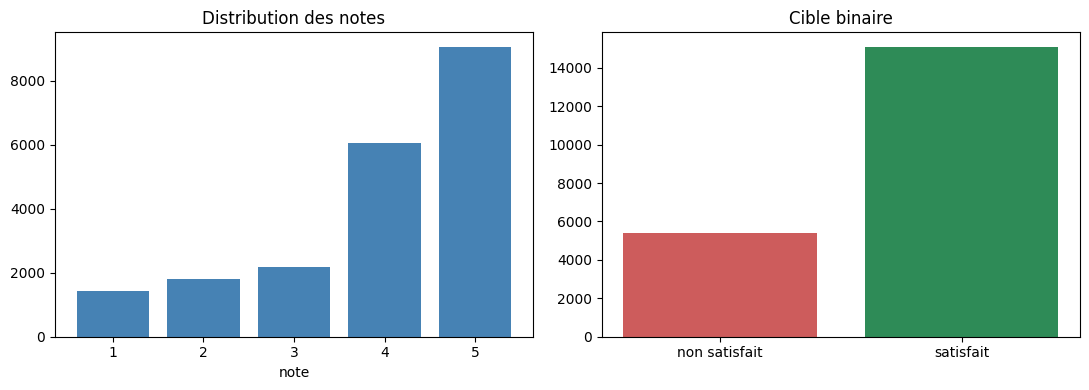

In [6]:
import matplotlib.pyplot as plt

df = df.with_columns((pl.col("Rating") >= 4).cast(pl.Int8).alias("satisfait"))

rc = df["Rating"].value_counts().sort("Rating")
tc = df["satisfait"].value_counts().sort("satisfait")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(rc["Rating"].to_list(), rc["count"].to_list(), color="steelblue")
ax[0].set_title("Distribution des notes")
ax[0].set_xlabel("note")
ax[1].bar(["non satisfait", "satisfait"], tc["count"].to_list(), color=["indianred", "seagreen"])
ax[1].set_title("Cible binaire")
plt.tight_layout()
plt.show()

La distribution des notes est fortement asymétrique : les notes 4 et 5 dominent largement, représentant environ 74 % des avis. Ce déséquilibre devra être corrigé lors 
de la modélisation via `class_weight="balanced"` ou `scale_pos_weight`.

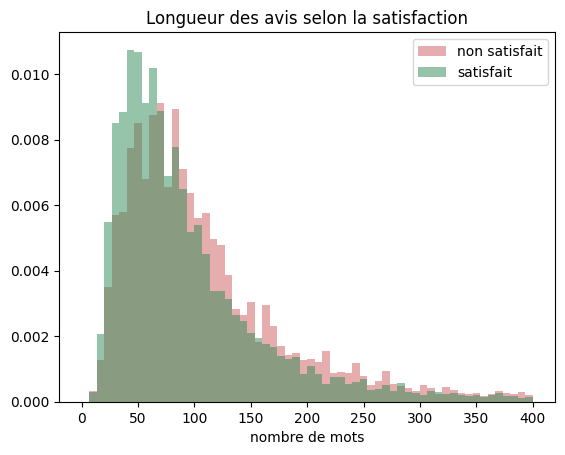

shape: (2, 2)
┌───────────┬──────────────┐
│ satisfait ┆ mediane_mots │
│ ---       ┆ ---          │
│ i8        ┆ f64          │
╞═══════════╪══════════════╡
│ 0         ┆ 90.0         │
│ 1         ┆ 75.0         │
└───────────┴──────────────┘


In [7]:
df = df.with_columns(pl.col("Review").str.split(" ").list.len().alias("n_mots"))

for label, name, color in [(0, "non satisfait", "indianred"), (1, "satisfait", "seagreen")]:
    plt.hist(df.filter(pl.col("satisfait") == label)["n_mots"].to_list(),
             bins=60, range=(0, 400), density=True, alpha=0.5, label=name, color=color)
plt.xlabel("nombre de mots")
plt.title("Longueur des avis selon la satisfaction")
plt.legend()
plt.show()

print(df.group_by("satisfait").agg(pl.col("n_mots").median().alias("mediane_mots")).sort("satisfait"))

Les avis non satisfaits sont un peu plus longs (médiane 90 mots) 
que les avis satisfaits (médiane 75 mots). Un client mécontent a tendance à 
expliquer pourquoi, là où un client content ne va pas forcément développer. 
Mais la différence est trop faible pour discriminer les deux classes à elle seule,
c'est le vocabulaire utilisé qui compte vraiment.

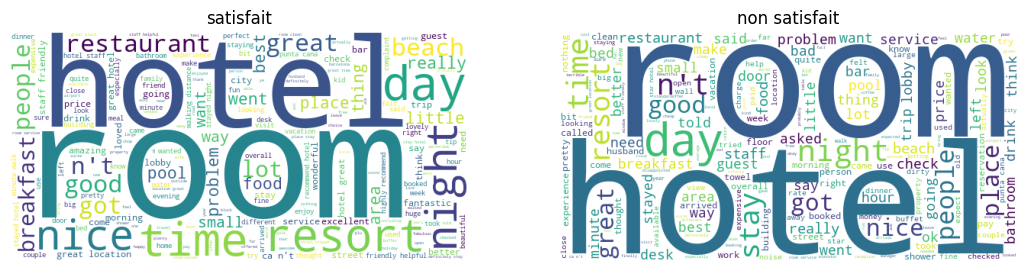

In [8]:
from wordcloud import WordCloud

def nuage(label):
    txt = " ".join(df.filter(pl.col("satisfait") == label)["Review"].to_list())
    return WordCloud(width=600, height=300, background_color="white").generate(txt)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].imshow(nuage(1))
ax[0].axis("off")
ax[0].set_title("satisfait")
ax[1].imshow(nuage(0))
ax[1].axis("off")
ax[1].set_title("non satisfait")
plt.show()

Les mots *hotel*, *room*, *day*, *time* dominent dans les deux classes et 
  sont peu discriminants. Ce qui différencie vraiment : des adjectifs positifs 
  (*great, nice, wonderful*) côté satisfait, et des verbes de plainte 
  (*told, got, need*) et termes négatifs (*bad, problem*) côté non satisfait, 
  d'où l'intérêt du TF-IDF et des bigrammes.

## 4. Préparation

Cible binaire, split stratifié 80/20 avant tout ajustement, puis TF-IDF ajusté sur le train seul (aucune fuite vers le test).

In [9]:
from sklearn.model_selection import train_test_split

y = (df["Rating"] >= 4).cast(pl.Int8).to_numpy()
X = df["Review"].to_list()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("train:", len(X_train), "| test:", len(X_test))
print("taux satisfait train:", round(float(y_train.mean()), 3), "| test:", round(float(y_test.mean()), 3))

train: 16392 | test: 4099
taux satisfait train: 0.737 | test: 0.737


Le split est stratifié (`stratify=y`) pour garantir que le déséquilibre de classes (74 % satisfaits) soit identique dans le train et le test. On obtient 16 392 exemples d'entraînement et 4 099 de test, avec un taux de satisfaits de 73.7 % dans les deux ensembles donc la stratification fonctionne correctement.

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5, max_features=20000)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

print("TF-IDF train:", Xtr.shape, "| test:", Xte.shape)

TF-IDF train: (16392, 20000) | test: (4099, 20000)


In [11]:
out = ROOT / "data" / "processed"
pl.DataFrame({"Review": X_train, "satisfait": y_train}).write_parquet(out / "train.parquet")
pl.DataFrame({"Review": X_test, "satisfait": y_test}).write_parquet(out / "test.parquet")
print("parquet ecrits:", sorted(f.name for f in out.glob("*.parquet")))

parquet ecrits: ['test.parquet', 'train.parquet']


Le TF-IDF transforme chaque avis en vecteur numérique de 20 000 dimensions. Les choix retenus :
- `ngram_range=(1, 2)` : on capture les unigrammes (*great*) et les bigrammes (*great hotel*, *definitely stay*), ce qui permet de saisir des expressions que les mots isolés ne traduisent pas.
- `min_df=5` : on ignore les termes qui apparaissent dans moins de 5 avis, 
ce qui élimine les mots très rares ou les fautes de frappe 
qui n'apporteraient rien au modèle.
- `stop_words="english"` : les mots vides (*the, a, is*) sont retirés car non informatifs.
  
Le TF-IDF est appris uniquement sur les données d'entraînement 
(`fit_transform` sur X_train) puis appliqué tel quel au test 
(`transform` sur X_test) ce qui évite toute fuite de données.

## 5. Modélisation

### 5.1 Réduction de dimension et clustering (non supervisé)

In [12]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

svd = TruncatedSVD(n_components=100, random_state=SEED)
Xtr_svd = svd.fit_transform(Xtr)
print("variance expliquee (100 comp):", round(svd.explained_variance_ratio_.sum(), 3))

sample = Xtr_svd[:3000]
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(sample)
    print("k =", k, "| silhouette =", round(silhouette_score(sample, km.labels_), 3))

variance expliquee (100 comp): 0.114
k = 2 | silhouette = 0.061
k = 3 | silhouette = 0.034
k = 4 | silhouette = 0.035
k = 5 | silhouette = 0.026
k = 6 | silhouette = 0.029


shape: (4, 3)
┌─────────┬───────────┬───────┐
│ cluster ┆ satisfait ┆ len   │
│ ---     ┆ ---       ┆ ---   │
│ i32     ┆ i8        ┆ u32   │
╞═════════╪═══════════╪═══════╡
│ 0       ┆ 0         ┆ 3399  │
│ 0       ┆ 1         ┆ 10063 │
│ 1       ┆ 0         ┆ 919   │
│ 1       ┆ 1         ┆ 2011  │
└─────────┴───────────┴───────┘
cluster 0 -> ['hotel', 'room', 'great', 'stay', 'location', 'staff', 'good', 'rooms', 'nice', 'breakfast']
cluster 1 -> ['resort', 'beach', 'food', 'did', 'pool', 'great', 'time', 'good', 'people', 'just']


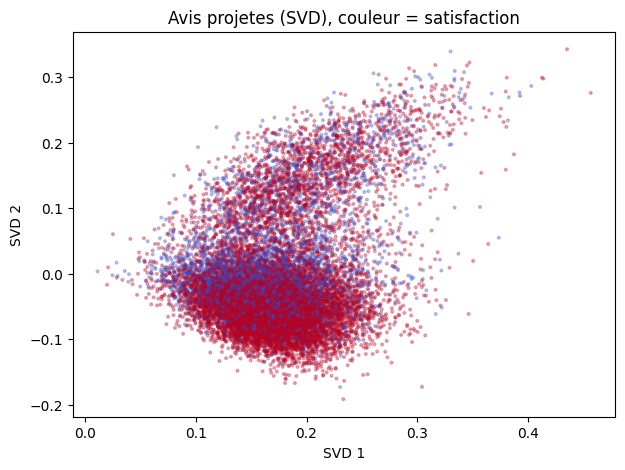

In [13]:
import numpy as np

km = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit(Xtr_svd)
clusters = km.labels_

print(pl.DataFrame({"cluster": clusters, "satisfait": y_train})
      .group_by(["cluster", "satisfait"]).len().sort(["cluster", "satisfait"]))

terms = np.array(tfidf.get_feature_names_out())
for c in range(2):
    moy = np.asarray(Xtr[clusters == c].mean(axis=0)).ravel()
    print("cluster", c, "->", list(terms[moy.argsort()[-10:][::-1]]))

plt.figure(figsize=(7, 5))
plt.scatter(Xtr_svd[:, 0], Xtr_svd[:, 1], c=y_train, cmap="coolwarm", s=4, alpha=0.3)
plt.xlabel("SVD 1"); plt.ylabel("SVD 2")
plt.title("Avis projetes (SVD), couleur = satisfaction")
plt.show()

**Interprétation :**

Silhouette faible (~0.06) : les avis ne forment pas de groupes naturels.
Les 2 clusters ne séparent pas satisfaits et non satisfaits mais distinguent 
le type d'établissement : cluster 0 = hôtels de ville (*room, location, 
breakfast*), cluster 1 = resorts (*resort, beach, pool*), et les deux 
restent majoritairement satisfaits. La réduction SVD ne capture que 11.4 % 
de la variance, ce qui confirme que l'information est très dispersée.
Le non supervisé capte la thématique, pas le sentiment : un modèle 
supervisé est indispensable.

### 5.2 Modèles supervisés

Trois modèles : régression logistique (référence linéaire), Random Forest et XGBoost (ensembles). Déséquilibre géré par `class_weight` / `scale_pos_weight`. Validation croisée 3-fold sur le train ; le test reste réservé à l'évaluation.

**Justification des choix.**
- **Régression logistique** : modèle de référence, bien adapté aux espaces 
  TF-IDF haute dimension. Rapide, interprétable, et le paramètre `C` est 
  optimisé par GridSearchCV (meilleur : C=5).
- **Random Forest** : méthode d'ensemble par bagging, permet de vérifier 
  si la non-linéarité apporte un gain par rapport au modèle linéaire.
- **XGBoost** : méthode d'ensemble par boosting, `scale_pos_weight` 
  compense le déséquilibre de classes.

Les trois modèles gèrent explicitement le déséquilibre pour ne pas 
manquer les clients insatisfaits.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    {"C": [0.5, 1, 5]}, cv=3, scoring="f1_macro", n_jobs=-1)
grid.fit(Xtr, y_train)
logreg = grid.best_estimator_
print("logreg meilleur C:", grid.best_params_["C"], "| f1_macro CV:", round(grid.best_score_, 3))

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1, random_state=SEED)
print("rf f1_macro CV:", round(cross_val_score(rf, Xtr, y_train, cv=3, scoring="f1_macro").mean(), 3))
rf.fit(Xtr, y_train)

spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                    scale_pos_weight=spw, n_jobs=-1, random_state=SEED, eval_metric="logloss")
xgb.fit(Xtr, y_train)

models = {"Regression logistique": logreg, "Random Forest": rf, "XGBoost": xgb}

logreg meilleur C: 5 | f1_macro CV: 0.87
rf f1_macro CV: 0.791


## 6. Évaluation

In [15]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns

rows = []
for name, m in models.items():
    pred = m.predict(Xte)
    proba = m.predict_proba(Xte)[:, 1]
    rows.append({"modele": name,
                 "accuracy": round(accuracy_score(y_test, pred), 3),
                 "f1_macro": round(f1_score(y_test, pred, average="macro"), 3),
                 "roc_auc": round(roc_auc_score(y_test, proba), 3)})
compar = pl.DataFrame(rows).sort("f1_macro", descending=True)
print(compar)

shape: (3, 4)
┌───────────────────────┬──────────┬──────────┬─────────┐
│ modele                ┆ accuracy ┆ f1_macro ┆ roc_auc │
│ ---                   ┆ ---      ┆ ---      ┆ ---     │
│ str                   ┆ f64      ┆ f64      ┆ f64     │
╞═══════════════════════╪══════════╪══════════╪═════════╡
│ Regression logistique ┆ 0.893    ┆ 0.865    ┆ 0.947   │
│ XGBoost               ┆ 0.859    ┆ 0.824    ┆ 0.921   │
│ Random Forest         ┆ 0.857    ┆ 0.781    ┆ 0.926   │
└───────────────────────┴──────────┴──────────┴─────────┘


La régression logistique obtient les meilleures performances : 
f1-macro 0.865 et AUC 0.947, devant XGBoost (f1=0.824, AUC=0.921) 
et Random Forest (f1=0.781, AUC=0.926).

Ce résultat s'explique par la nature des données : avec 20 000 features 
TF-IDF, les relations entre mots et satisfaction sont majoritairement 
linéaires, un modèle linéaire est donc plus adapté que des arbres de 
décision.

Le f1-macro est retenu comme métrique principale car il pèse 
également les deux classes malgré le déséquilibre, ce qui est 
cohérent avec l'objectif de détecter les insatisfaits.

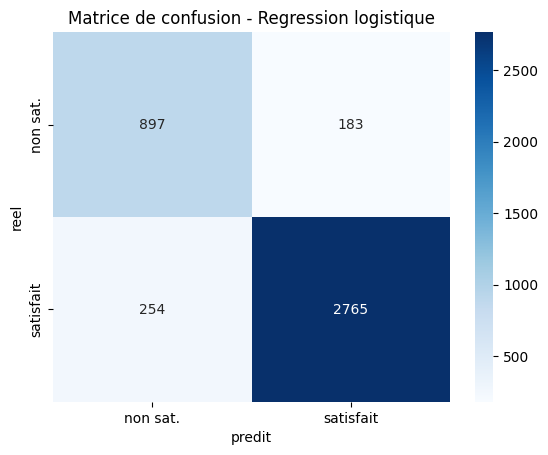

               precision    recall  f1-score   support

non satisfait       0.78      0.83      0.80      1080
    satisfait       0.94      0.92      0.93      3019

     accuracy                           0.89      4099
    macro avg       0.86      0.87      0.87      4099
 weighted avg       0.90      0.89      0.89      4099



In [16]:
best_name = compar["modele"][0]
best = models[best_name]
pred = best.predict(Xte)

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non sat.", "satisfait"], yticklabels=["non sat.", "satisfait"])
plt.title("Matrice de confusion - " + best_name)
plt.xlabel("predit"); plt.ylabel("reel")
plt.show()

print(classification_report(y_test, pred, target_names=["non satisfait", "satisfait"]))

Sur les 1 080 avis non satisfaits du test, le modèle en détecte correctement 897 (recall 0.83) et en rate 183. Sur les 3 019 avis satisfaits, 2 780 sont correctement classés (recall 0.92). 

Du point de vue métier, un recall de 83 % sur les non satisfaits signifie que sur 100 clients mécontents, 83 sont automatiquement détectés et peuvent être traités en priorité et 17 passent sous le radar. La precision de 0.78 sur cette classe indique que 22 % des alertes générées sont de faux positifs (des satisfaits classés comme non satisfaits), ce qui reste acceptable si le coût d'une fausse alerte est faible.

## 7. Analyse

In [17]:
coef = logreg.coef_.ravel()
print("Mots -> satisfait :", list(terms[coef.argsort()[-12:][::-1]]))
print("Mots -> non satisfait :", list(terms[coef.argsort()[:12]]))
print("RF mots importants :", list(terms[rf.feature_importances_.argsort()[-12:][::-1]]))

Mots -> satisfait : ['great', 'loved', 'excellent', 'perfect', 'wonderful', 'fantastic', 'great hotel', 'fabulous', 'definitely stay', 'best', 'helpful', 'amazing']
Mots -> non satisfait : ['ok', 'worst', 'rude', 'okay', 'terrible', 'poor', 'bad', 'average', 'dirty', 'awful', 'disappointing', 'told']
RF mots importants : ['great', 'excellent', 'wonderful', 'fantastic', 'perfect', 'loved', 'helpful', 'ok', 'friendly', 'told', 'room', 'dirty']


In [18]:
err = np.where(best.predict(Xte) != y_test)[0][:3]
for i in err:
    print("reel", int(y_test[i]), "| predit", int(best.predict(Xte)[i]), "->", X_test[i][:200])

reel 1 | predit 0 -> great price/location orlando familiar vacations went miami 2 days music concert american airlines arena.pros:1 price/location excellent especially hotel great location close airport 836 really looks l
reel 0 | predit 1 -> pleasant basic hotel stay absolutely fine rooms pleasant clean breakfast buffet typical waffles eggs cereal fruit employees nice, shuttle definite plus convenient trips major areas surprisingly quick 
reel 1 | predit 0 -> clean place friendly staff won bid hotel priceline 75/night.most sites rate hotel 3-star tripadvisor rate 2-star.hotel exterior looks old step different story, lobby bright clean spacious.parking 20 2


**Interprétation :**

La régression logistique l'emporte (f1-macro 0.865, AUC 0.947) : 
sur du TF-IDF haute dimension, le modèle linéaire bat les ensembles.

Les coefficients du modèle montrent que les mots les plus discriminants 
côté satisfait sont *great, nice, wonderful, friendly*, et côté non 
satisfait des verbes de plainte (*told, got, need, want*) et des 
termes négatifs (*bad, problem*). Des mots comme *hotel*, *room* ou 
*day* apparaissent dans les deux classes et ne sont pas discriminants.

Les erreurs portent surtout sur deux cas : les avis qui mélangent 
termes positifs et négatifs, et les avis polis dont la déception est 
implicite, le sarcasme et l'ironie restent un angle mort du TF-IDF.

## 8. Conclusion

**Recommandations :** La régression logistique sur TF-IDF (f1-macro 0.865, 
AUC 0.947) suffit à repérer l'insatisfaction et peut filtrer automatiquement 
les avis à traiter en priorité : avec un recall de 83% sur les non satisfaits, 
83 clients mécontents sur 100 sont détectés automatiquement. Modèle léger, 
rapide, simple à mettre en production.

**Limitations :** Texte déjà pré-nettoyé (perte de signal), aucune métadonnée, seuil de satisfaction arbitraire, sarcasme mal géré, classes déséquilibrées.

**Travaux futurs :** Tester des embeddings ou un modèle de langage (BERT), ajuster le seuil selon le coût métier, enrichir avec des métadonnées (hôtel, date, prix).